In [1]:
from pathlib import Path
from cellbender.remove_background.downstream import load_anndata_from_input_and_output
import scanpy as sc

In [2]:
BATCH = 1
tissue = 'blood'
PT = "PT-212"
side = "R"

if BATCH==1:
    batch_path = Path("../LBP_brain_blood_pairs/data/narsad_cellRanger_outs/")
else:
    batch_path = Path()

file_path = batch_path / tissue/  f"{PT}-blood-{side}"
adata = load_anndata_from_input_and_output(input_file=file_path /  'raw_feature_bc_matrix.h5', output_file=file_path/  f"{PT}-{side}-B_CellBender.h5")

In [3]:
adata

AnnData object with n_obs × n_vars = 10542 × 36601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_cellranger', 'n_cellbender'
    var: 'ambient_expression', 'feature_type', 'genome', 'gene_id', 'cellbender_analyzed', 'n_cellranger', 'n_cellbender'
    uns: 'cell_size_lognormal_std', 'empty_droplet_size_lognormal_loc', 'empty_droplet_size_lognormal_scale', 'swapping_fraction_dist_params', 'estimator', 'features_analyzed_inds', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_learning_rate_value', 'learning_curve_test_elbo', 'learning_curve_test_epoch', 'learning_curve_train_elbo', 'learning_curve_train_epoch', 'target_false_positive_rate'
    obsm: 'cellbender_embedding'
    layers: 'cellranger', 'cellbender'

In [4]:
# preprocess raw data
adata.X = adata.layers['cellranger'].copy()
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat_v3')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(adata, use_rep='X_pca')

# UMAP of raw data
sc.tl.umap(adata)
adata.obsm['X_umap_raw'] = adata.obsm['X_umap'].copy()

# preprocess cellbender data
adata.X = adata.layers['cellbender'].copy()
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat_v3')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.pca(adata, n_comps=20, use_highly_variable=True)
sc.pp.neighbors(adata, use_rep='X_pca')

# UMAP of raw data
sc.tl.umap(adata)
adata.obsm['X_umap_cellbender'] = adata.obsm['X_umap'].copy()

del adata.obsm['X_umap']

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-pac

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


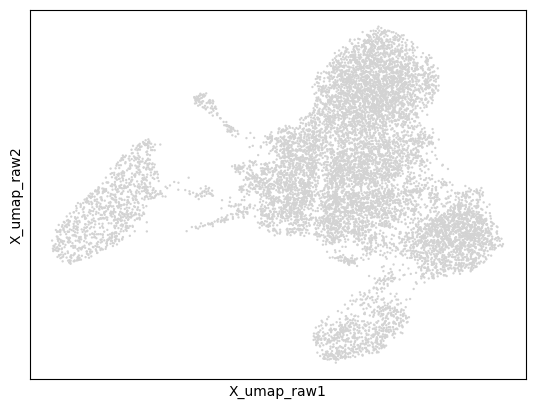

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


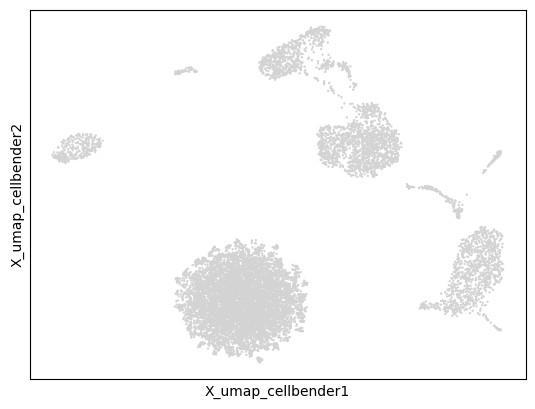

In [5]:
sc.pl.embedding(adata, basis='X_umap_raw')
sc.pl.embedding(adata, basis='X_umap_cellbender')